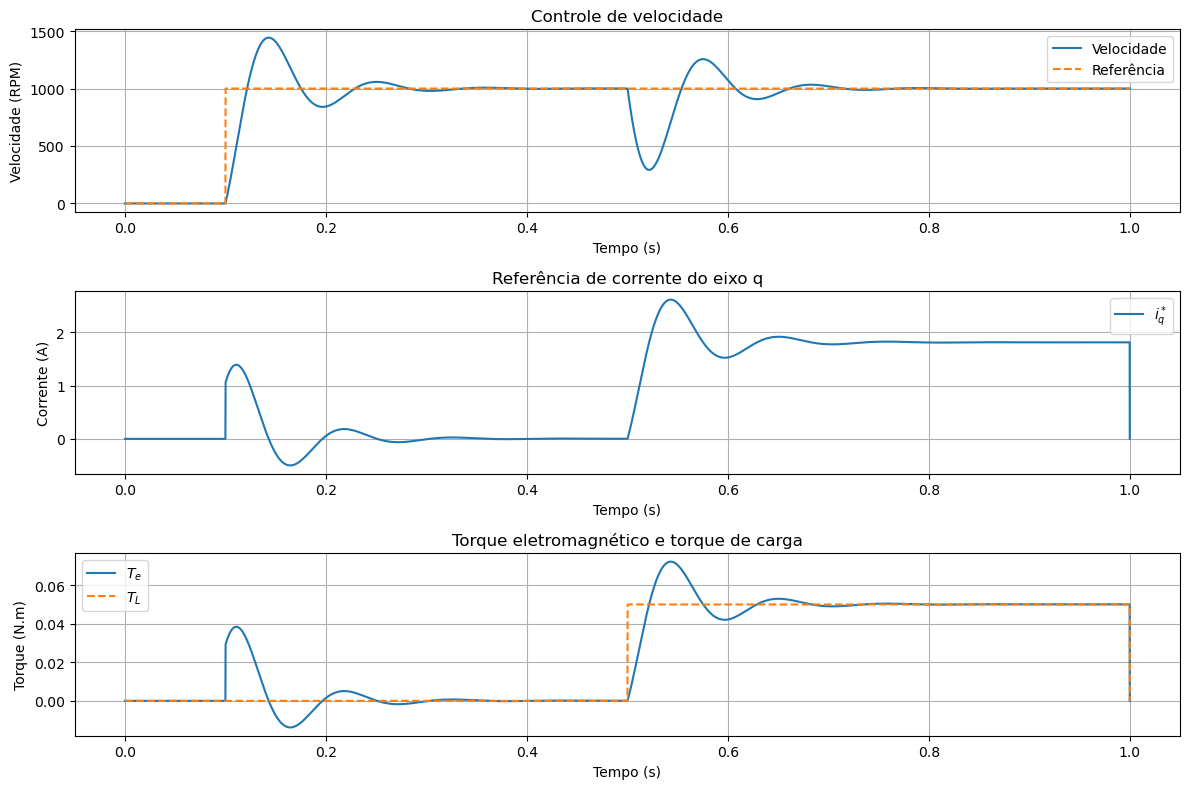

In [2]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

from bldc import bldc, PIController


# ============================================================
# PARÂMETROS DO MOTOR
# ============================================================

Rs = 0.6
L = 5e-3

Ke = 0.0276
Kt = Ke

B = 7.312e-7
J = 7.312e-6

POLOS = 8
PARES_DE_POLOS = POLOS / 2

Vdc = 24


# ============================================================
# PARÂMETROS DA SIMULAÇÃO
# ============================================================

ti = 0.0
tf = 1.0
dt = 1e-4

N = int((tf - ti) / dt)

time = np.arange(ti, tf, dt)


# ============================================================
# REFERÊNCIA DE VELOCIDADE
# ============================================================

omega_ref_rpm = 1000

omega_ref = (
    omega_ref_rpm * 2*pi / 60
)


# ============================================================
# MOTOR
# ============================================================

motor = bldc(
    R=Rs,
    L=L,
    B=B,
    J=J,
    Ke=Ke,
    Kt=Kt,
    P=PARES_DE_POLOS,
    Vdc=Vdc
)


# ============================================================
# CONTROLADOR DE VELOCIDADE
# ============================================================

speed_controller = PIController(
    Kp=0.01,
    Ki=1.0,
    Ts=dt,

    # Saída do PI:
    # referência de corrente iq*
    output_min=-10,
    output_max=10
)


# ============================================================
# VARIÁVEIS DA SIMULAÇÃO
# ============================================================

omega = np.zeros(N)

iq_ref = np.zeros(N)

torque = np.zeros(N)

load_torque = np.zeros(N)


# ============================================================
# SIMULAÇÃO
# ============================================================

for k in range(N - 1):

    # --------------------------------------------------------
    # Referência de velocidade
    # --------------------------------------------------------

    if time[k] < 0.1:

        omega_ref_k = 0.0

    else:

        omega_ref_k = omega_ref


    # --------------------------------------------------------
    # Erro de velocidade
    # --------------------------------------------------------

    speed_error = (
        omega_ref_k - omega[k]
    )


    # --------------------------------------------------------
    # PI DE VELOCIDADE
    # --------------------------------------------------------

    iq_ref[k] = speed_controller.update(
        speed_error
    )


    # --------------------------------------------------------
    # MODELO SIMPLIFICADO DO TORQUE
    # --------------------------------------------------------
    #
    # Nesta primeira simulação, assumimos que o
    # controlador de corrente consegue fazer:
    #
    # iq = iq_ref
    #
    # Portanto:
    #
    # Te = Kt * iq
    #

    torque[k] = Kt * iq_ref[k]


    # --------------------------------------------------------
    # CARGA
    # --------------------------------------------------------

    if time[k] > 0.5:

        load_torque[k] = 0.05

    else:

        load_torque[k] = 0.0


    # --------------------------------------------------------
    # DINÂMICA MECÂNICA
    # --------------------------------------------------------

    domega = (
        torque[k]
        - load_torque[k]
        - B * omega[k]
    ) / J


    # --------------------------------------------------------
    # INTEGRAÇÃO
    # --------------------------------------------------------

    omega[k + 1] = (
        omega[k]
        + domega * dt
    )


# ============================================================
# CONVERSÃO PARA RPM
# ============================================================

omega_rpm = (
    omega * 60 / (2*pi)
)


# ============================================================
# GRÁFICOS
# ============================================================

plt.figure(figsize=(12, 8))


# ------------------------------------------------------------
# VELOCIDADE
# ------------------------------------------------------------

plt.subplot(311)

plt.plot(
    time,
    omega_rpm,
    label="Velocidade"
)

plt.plot(
    time,
    np.where(
        time < 0.1,
        0,
        omega_ref_rpm
    ),
    "--",
    label="Referência"
)

plt.title(
    "Controle de velocidade"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade (RPM)")

plt.grid()
plt.legend()


# ------------------------------------------------------------
# REFERÊNCIA DE CORRENTE
# ------------------------------------------------------------

plt.subplot(312)

plt.plot(
    time,
    iq_ref,
    label=r"$i_q^*$"
)

plt.title(
    "Referência de corrente do eixo q"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Corrente (A)")

plt.grid()
plt.legend()


# ------------------------------------------------------------
# TORQUE
# ------------------------------------------------------------

plt.subplot(313)

plt.plot(
    time,
    torque,
    label=r"$T_e$"
)

plt.plot(
    time,
    load_torque,
    "--",
    label=r"$T_L$"
)

plt.title(
    "Torque eletromagnético e torque de carga"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Torque (N.m)")

plt.grid()
plt.legend()


plt.tight_layout()

plt.show()

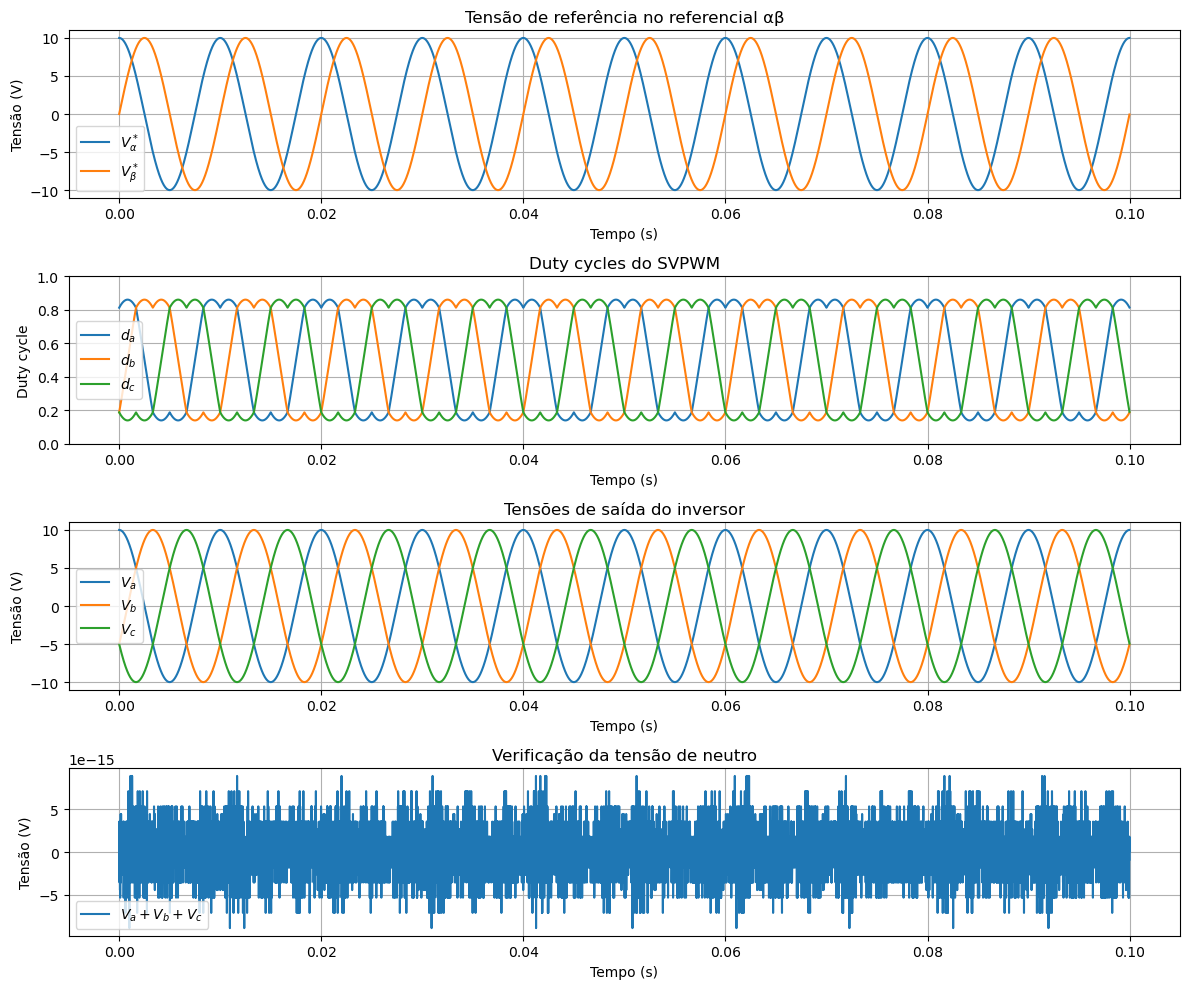

In [3]:
import importlib
from bldc import BLDC
from Inverter import Inverter
from SVPWM import SVPWM
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PARÂMETROS
# ============================================================

Vdc = 24.0

f_ref = 100.0

omega_ref = 2 * np.pi * f_ref

Vref = 10.0

ti = 0.0
tf = 0.1

dt = 1e-5

time = np.arange(
    ti,
    tf,
    dt
)

N = len(time)


# ============================================================
# OBJETOS
# ============================================================

inverter = Inverter(
    Vdc=Vdc
)

svpwm1 = SVPWM(
    Hz=10000,
    Vdc=24
)


# ============================================================
# VETORES DE REFERÊNCIA
# ============================================================

Valpha_ref = np.zeros(N)
Vbeta_ref = np.zeros(N)


# ============================================================
# DUTY CYCLES
# ============================================================

duty_a = np.zeros(N)
duty_b = np.zeros(N)
duty_c = np.zeros(N)


# ============================================================
# TENSÕES DE SAÍDA
# ============================================================

Va = np.zeros(N)
Vb = np.zeros(N)
Vc = np.zeros(N)


# ============================================================
# SIMULAÇÃO
# ============================================================

for k in range(N):

    t = time[k]

    # --------------------------------------------------------
    # Vetor espacial de tensão girante
    # --------------------------------------------------------

    theta = omega_ref * t

    Valpha_ref[k] = (
        Vref * np.cos(theta)
    )

    Vbeta_ref[k] = (
        Vref * np.sin(theta)
    )


    # --------------------------------------------------------
    # SVPWM
    # --------------------------------------------------------

    duty = svpwm1.modulate(
        Valpha_ref[k],
        Vbeta_ref[k]
    )

    duty_a[k] = duty[0]
    duty_b[k] = duty[1]
    duty_c[k] = duty[2]


    # --------------------------------------------------------
    # INVERSOR
    # --------------------------------------------------------

    Vabc = inverter.output_voltage(
        duty_a[k],
        duty_b[k],
        duty_c[k]
    )

    Va[k] = Vabc[0]
    Vb[k] = Vabc[1]
    Vc[k] = Vabc[2]

plt.figure(figsize=(12, 10))


# ============================================================
# TENSÕES DE REFERÊNCIA αβ
# ============================================================

plt.subplot(411)

plt.plot(
    time,
    Valpha_ref,
    label=r"$V_\alpha^*$"
)

plt.plot(
    time,
    Vbeta_ref,
    label=r"$V_\beta^*$"
)

plt.title(
    "Tensão de referência no referencial αβ"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


# ============================================================
# DUTY CYCLES
# ============================================================

plt.subplot(412)

plt.plot(
    time,
    duty_a,
    label=r"$d_a$"
)

plt.plot(
    time,
    duty_b,
    label=r"$d_b$"
)

plt.plot(
    time,
    duty_c,
    label=r"$d_c$"
)

plt.title(
    "Duty cycles do SVPWM"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Duty cycle")

plt.ylim(
    0,
    1
)

plt.grid()
plt.legend()


# ============================================================
# TENSÕES DE FASE
# ============================================================

plt.subplot(413)

plt.plot(
    time,
    Va,
    label=r"$V_a$"
)

plt.plot(
    time,
    Vb,
    label=r"$V_b$"
)

plt.plot(
    time,
    Vc,
    label=r"$V_c$"
)

plt.title(
    "Tensões de saída do inversor"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


# ============================================================
# VERIFICAÇÃO DA SOMA DAS TENSÕES
# ============================================================

plt.subplot(414)

plt.plot(
    time,
    Va + Vb + Vc,
    label=r"$V_a+V_b+V_c$"
)

plt.title(
    "Verificação da tensão de neutro"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


plt.tight_layout()

plt.show()

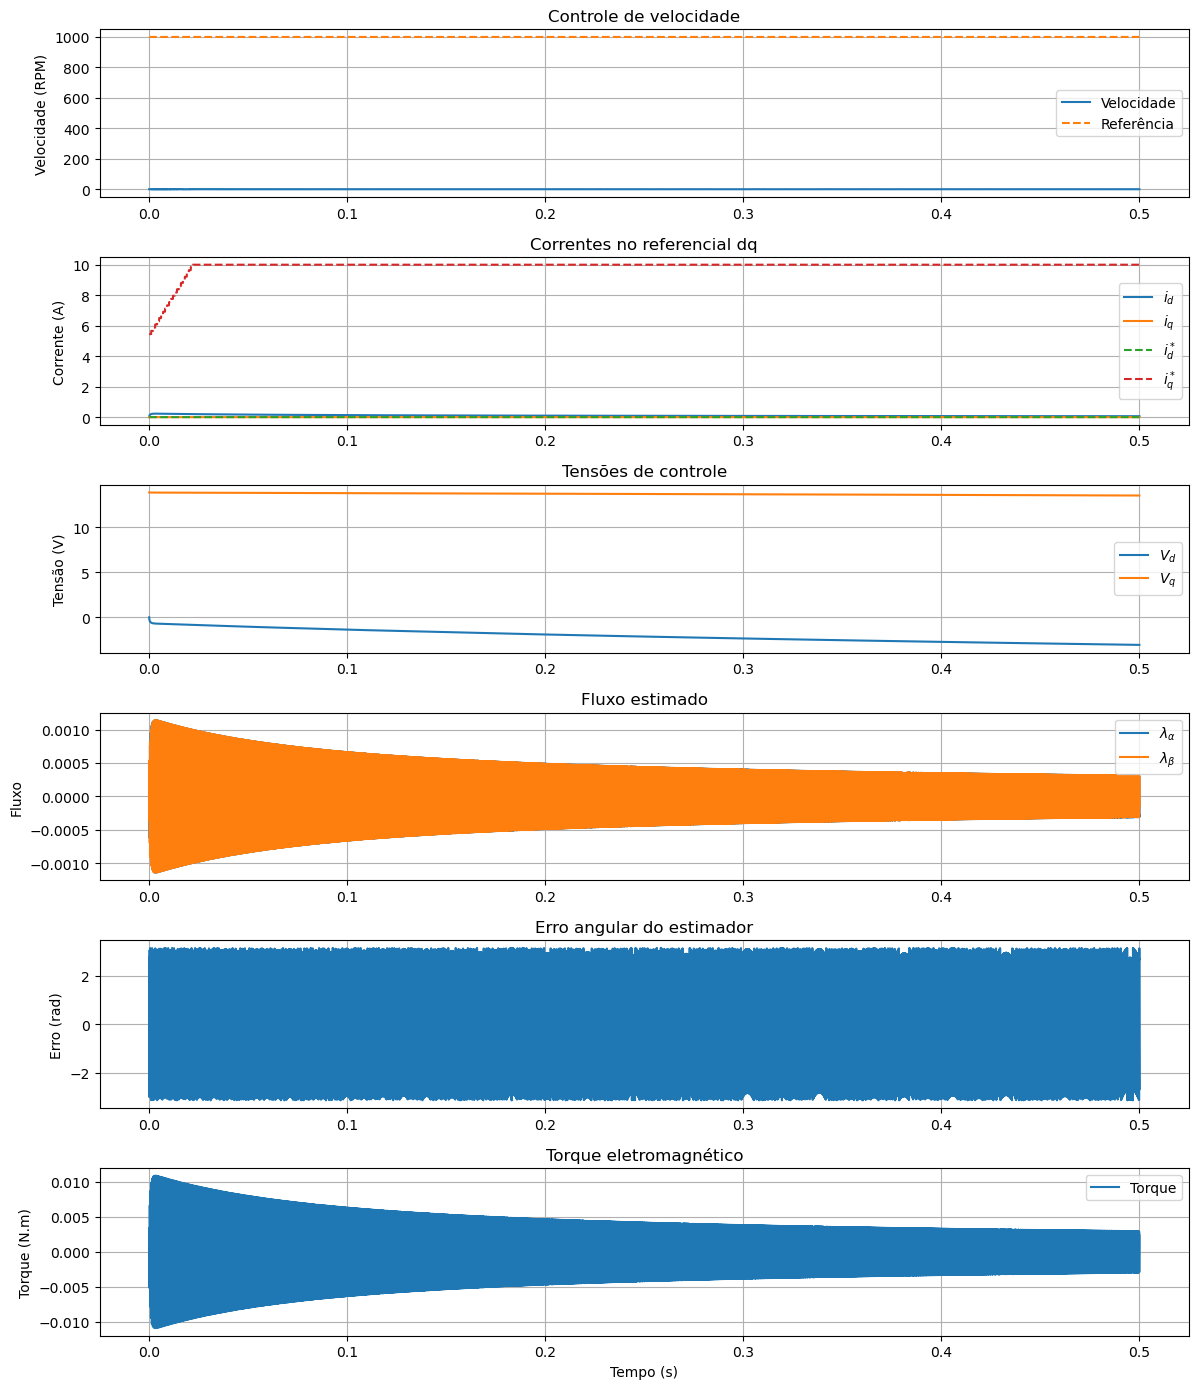

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from bldc import bldc, svpwm, PIController, Inverter


# ============================================================
# PARÂMETROS DO MOTOR
# ============================================================

Rs = 0.6
L = 5e-3

Ke = 0.0276
Kt = Ke

B = 7.312e-7
J = 7.312e-6

POLOS = 8
PARES_DE_POLOS = POLOS / 2

Vdc = 24.0


# ============================================================
# PARÂMETROS DA SIMULAÇÃO
# ============================================================

ti = 0.0
tf = 0.5

dt = 1e-5

time = np.arange(
    ti,
    tf,
    dt
)

N = len(time)


# ============================================================
# PERÍODOS DOS CONTROLADORES
# ============================================================

Ts_current = 1e-5
Ts_speed = 1e-3

current_control_period = int(Ts_current / dt)
speed_control_period = int(Ts_speed / dt)


# ============================================================
# OBJETOS
# ============================================================

motor = bldc(
    R=Rs,
    L=L,
    B=B,
    J=J,
    Ke=Ke,
    Kt=Kt,
    P=PARES_DE_POLOS,
    Vdc=Vdc
)

inverter = Inverter(
    Vdc=Vdc
)

svpwm1 = svpwm(
    Hz=1 / Ts_current,
    Vdc=Vdc
)


# ============================================================
# CONTROLADOR DE VELOCIDADE
# ============================================================

speed_controller = PIController(
    Kp=0.05,
    Ki=2.0,
    Ts=Ts_speed,

    # Saída = referência de corrente iq
    output_min=-10.0,
    output_max=10.0
)


# ============================================================
# CONTROLADORES DE CORRENTE
# ============================================================

id_controller = PIController(
    Kp=5.0,
    Ki=100.0,
    Ts=Ts_current,

    output_min=-Vdc,
    output_max=Vdc
)

iq_controller = PIController(
    Kp=5.0,
    Ki=100.0,
    Ts=Ts_current,

    output_min=-Vdc,
    output_max=Vdc
)


# ============================================================
# REFERÊNCIA DE VELOCIDADE
# ============================================================

rpm_ref = 1000.0

omega_ref = motor.rpm_to_rads(
    rpm_ref
)


# ============================================================
# REFERÊNCIAS DE CORRENTE
# ============================================================

id_ref = 0.0
iq_ref = 0.0


# ============================================================
# VARIÁVEIS DO CONTROLADOR
# ============================================================

vd = 0.0
vq = 0.0


# ============================================================
# ESTIMADOR DE FLUXO
# ============================================================

lambda_alpha = 0.0
lambda_beta = 0.0

theta_est = 0.0

# Ganho de compensação do integrador
K_flux = 10.0


# ============================================================
# ARRAYS
# ============================================================

omega_array = np.zeros(N)
rpm_array = np.zeros(N)
omega_ref_array = np.zeros(N)

theta_real_array = np.zeros(N)
theta_est_array = np.zeros(N)

lambda_alpha_array = np.zeros(N)
lambda_beta_array = np.zeros(N)

ia_array = np.zeros(N)
ib_array = np.zeros(N)
ic_array = np.zeros(N)

ialpha_array = np.zeros(N)
ibeta_array = np.zeros(N)

id_array = np.zeros(N)
iq_array = np.zeros(N)

id_ref_array = np.zeros(N)
iq_ref_array = np.zeros(N)

vd_array = np.zeros(N)
vq_array = np.zeros(N)

valpha_array = np.zeros(N)
vbeta_array = np.zeros(N)

duty_a_array = np.zeros(N)
duty_b_array = np.zeros(N)
duty_c_array = np.zeros(N)

Te_array = np.zeros(N)


# ============================================================
# SIMULAÇÃO
# ============================================================

for k in range(N):

    # ========================================================
    # ESTADO ATUAL DO MOTOR
    # ========================================================

    omega = motor.omega_r

    ia = motor.ia
    ib = motor.ib
    ic = motor.ic


    # ========================================================
    # REFERÊNCIA DE VELOCIDADE
    # ========================================================

    omega_ref_array[k] = omega_ref


    # ========================================================
    # CONTROLADOR DE VELOCIDADE
    # ========================================================

    if k % speed_control_period == 0:

        error_speed = (
            omega_ref - omega
        )

        iq_ref = speed_controller.update(
            error_speed
        )


    # ========================================================
    # TRANSFORMAÇÃO DE CLARKE DAS CORRENTES
    # ========================================================

    i_alpha_beta = motor.Clarke(
        np.array([
            ia,
            ib,
            ic
        ])
    )

    i_alpha = i_alpha_beta[0]
    i_beta = i_alpha_beta[1]


    # ========================================================
    # ESTIMADOR DE FLUXO
    #
    # λ = ∫(V - Rs*i)dt
    #
    # A tensão utilizada é a tensão REAL aplicada pelo inversor
    # no passo anterior.
    # ========================================================

    if k > 0:

        lambda_alpha += (
            valpha_array[k - 1]
            - Rs * ialpha_array[k - 1]
            - K_flux * lambda_alpha
        ) * dt

        lambda_beta += (
            vbeta_array[k - 1]
            - Rs * ibeta_array[k - 1]
            - K_flux * lambda_beta
        ) * dt


    # ========================================================
    # ESTIMAÇÃO DO ÂNGULO
    # ========================================================

    theta_est = np.arctan2(
        lambda_beta,
        lambda_alpha
    )

    theta_est = np.mod(
        theta_est,
        2 * np.pi
    )


    # ========================================================
    # TRANSFORMAÇÃO DE PARK
    # ========================================================

    idq = motor.Park(
        np.array([
            i_alpha,
            i_beta
        ]),
        theta_est
    )

    id = idq[0]
    iq = idq[1]


    # ========================================================
    # CONTROLADORES DE CORRENTE
    # ========================================================

    if k % current_control_period == 0:

        error_id = (
            id_ref - id
        )

        error_iq = (
            iq_ref - iq
        )

        vd = id_controller.update(
            error_id
        )

        vq = iq_controller.update(
            error_iq
        )


    # ========================================================
    # LIMITAÇÃO DO VETOR DE TENSÃO
    # ========================================================

    Vmax = Vdc / np.sqrt(3)

    voltage_magnitude = np.hypot(
        vd,
        vq
    )

    if voltage_magnitude > Vmax:

        scale = Vmax / voltage_magnitude

        vd *= scale
        vq *= scale


    # ========================================================
    # TRANSFORMAÇÃO INVERSA DE PARK
    # ========================================================

    valpha_beta = motor.ParkInverse(
        np.array([
            vd,
            vq
        ]),
        theta_est
    )

    valpha = valpha_beta[0]
    vbeta = valpha_beta[1]


    # ========================================================
    # SVPWM
    # ========================================================

    duty = svpwm1.modulate(
        valpha,
        vbeta
    )

    duty_a = duty[0]
    duty_b = duty[1]
    duty_c = duty[2]


    # ========================================================
    # INVERSOR
    # ========================================================

    Vabc = inverter.output_voltage(
        duty_a,
        duty_b,
        duty_c
    )

    Va = Vabc[0]
    Vb = Vabc[1]
    Vc = Vabc[2]


    # ========================================================
    # MOTOR
    # ========================================================

    state = motor.step(
        Va=Va,
        Vb=Vb,
        Vc=Vc,
        Tl=0.0,
        dt=dt
    )


    # ========================================================
    # ARMAZENAMENTO
    # ========================================================

    omega_array[k] = state["omega_r"]

    rpm_array[k] = motor.rads_to_rpm(
        state["omega_r"]
    )

    theta_real_array[k] = (
        motor.P * motor.theta_r
    )

    theta_est_array[k] = theta_est


    lambda_alpha_array[k] = lambda_alpha
    lambda_beta_array[k] = lambda_beta


    ia_array[k] = state["ia"]
    ib_array[k] = state["ib"]
    ic_array[k] = state["ic"]


    ialpha_array[k] = i_alpha
    ibeta_array[k] = i_beta


    id_array[k] = id
    iq_array[k] = iq


    id_ref_array[k] = id_ref
    iq_ref_array[k] = iq_ref


    vd_array[k] = vd
    vq_array[k] = vq


    valpha_array[k] = valpha
    vbeta_array[k] = vbeta


    duty_a_array[k] = duty_a
    duty_b_array[k] = duty_b
    duty_c_array[k] = duty_c


    Te_array[k] = state["Te"]


# ============================================================
# ERRO DE ÂNGULO
# ============================================================

angle_error = (
    theta_real_array
    - theta_est_array
)

angle_error = (
    np.arctan2(
        np.sin(angle_error),
        np.cos(angle_error)
    )
)


# ============================================================
# GRÁFICOS
# ============================================================

plt.figure(figsize=(12, 14))


# ------------------------------------------------------------
# VELOCIDADE
# ------------------------------------------------------------

plt.subplot(611)

plt.plot(
    time,
    rpm_array,
    label="Velocidade"
)

plt.plot(
    time,
    motor.rads_to_rpm(
        omega_ref_array
    ),
    "--",
    label="Referência"
)

plt.title(
    "Controle de velocidade"
)

plt.ylabel(
    "Velocidade (RPM)"
)

plt.grid()
plt.legend()


# ------------------------------------------------------------
# CORRENTES DQ
# ------------------------------------------------------------

plt.subplot(612)

plt.plot(
    time,
    id_array,
    label=r"$i_d$"
)

plt.plot(
    time,
    iq_array,
    label=r"$i_q$"
)

plt.plot(
    time,
    id_ref_array,
    "--",
    label=r"$i_d^*$"
)

plt.plot(
    time,
    iq_ref_array,
    "--",
    label=r"$i_q^*$"
)

plt.title(
    "Correntes no referencial dq"
)

plt.ylabel(
    "Corrente (A)"
)

plt.grid()
plt.legend()


# ------------------------------------------------------------
# TENSÕES DQ
# ------------------------------------------------------------

plt.subplot(613)

plt.plot(
    time,
    vd_array,
    label=r"$V_d$"
)

plt.plot(
    time,
    vq_array,
    label=r"$V_q$"
)

plt.title(
    "Tensões de controle"

)

plt.ylabel(
    "Tensão (V)"
)

plt.grid()
plt.legend()


# ------------------------------------------------------------
# FLUXO
# ------------------------------------------------------------

plt.subplot(614)

plt.plot(
    time,
    lambda_alpha_array,
    label=r"$\lambda_\alpha$"
)

plt.plot(
    time,
    lambda_beta_array,
    label=r"$\lambda_\beta$"
)

plt.title(
    "Fluxo estimado"

)

plt.ylabel(
    "Fluxo"

)

plt.grid()
plt.legend()


# ------------------------------------------------------------
# ERRO ANGULAR
# ------------------------------------------------------------

plt.subplot(615)

plt.plot(
    time,
    angle_error
)

plt.title(
    "Erro angular do estimador"
)

plt.ylabel(
    "Erro (rad)"
)

plt.grid()


# ------------------------------------------------------------
# TORQUE
# ------------------------------------------------------------

plt.subplot(616)

plt.plot(
    time,
    Te_array,
    label="Torque"
)

plt.title(
    "Torque eletromagnético"
)

plt.xlabel(
    "Tempo (s)"
)

plt.ylabel(
    "Torque (N.m)"
)

plt.grid()
plt.legend()


plt.tight_layout()

plt.show()